## Imports

In [121]:
import tensorflow as tf

import os
import datetime
import time

import pyvista as pv
from matplotlib import pyplot as plt
from IPython import display
import numpy as np

plt.style.use('ggplot')

# `pix2pix` implementation

### Load .vti files and convert to tensor

In [122]:
def resize(input_image, real_image=None, height=256, width=256):
  input_image = tf.expand_dims(input_image, axis=-1)

  input_image = tf.image.resize(input_image, [height, width],
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

  if real_image != None:
    real_image = tf.expand_dims(real_image, axis=-1)
    real_image = tf.image.resize(real_image, [height, width],
                                method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    return input_image, real_image

  return input_image, None

def load(input_file_path, real_file_path=None):
    input_grid = pv.read(input_file_path)
    input_data = input_grid.active_scalars
    input_dims = input_grid.dimensions
    input_nx, input_ny = input_dims[0], input_dims[1]

    input_image = input_data.reshape((input_ny, input_nx))
    input_tensor = tf.convert_to_tensor(input_image, dtype=tf.float32)

    if real_file_path:
      real_grid = pv.read(real_file_path)
      real_data = real_grid.active_scalars
      real_dims = real_grid.dimensions
      real_nx, real_ny = real_dims[0], real_dims[1]

      real_image = real_data.reshape((real_ny, real_nx))
      real_tensor = tf.convert_to_tensor(real_image, dtype=tf.float32)

      return resize(input_tensor, real_tensor, 256, 256)

    return resize(input_tensor, None, 256, 256)

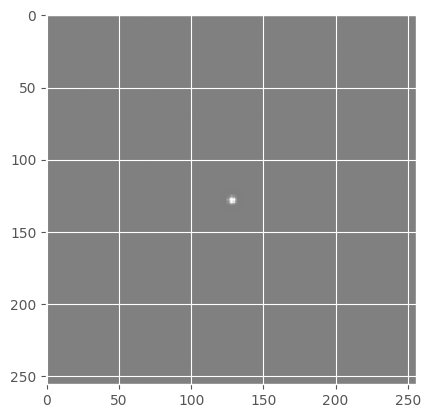

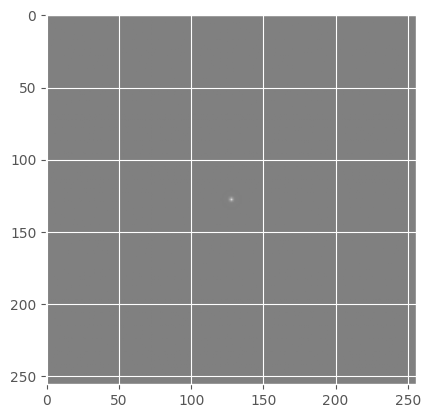

In [123]:
inp, re = load('../sample/constant_vel/coarse_grid/output_data_0_15.vti', '../sample/constant_vel/refined_grid/output_data_0_15.vti')

plt.figure()
plt.imshow(inp, cmap='grey', vmin=-.5, vmax=.5)
plt.figure()
plt.imshow(re, cmap='grey', vmin=-.5, vmax=.5)

### Split data into training/testing

In [124]:
! rm ../train/*
! rm ../test/*

# ! bash ../scripts/split_data.sh ../sample/constant_vel/coarse_grid "output_data_0" "input"
# ! bash ../scripts/split_data.sh ../sample/constant_vel/refined_grid "output_data_0" "real"

# ! bash ../scripts/split_data.sh ../sample/parallel/coarse_grid "output_data_0" "input"
# ! bash ../scripts/split_data.sh ../sample/parallel/refined_grid "output_data_0" "real"

# ! bash ../scripts/split_data.sh ../sample/semicircle/coarse_grid "output_data_0" "input"
# ! bash ../scripts/split_data.sh ../sample/semicircle/refined_grid "output_data_0" "real"

# ! bash ../scripts/split_data.sh ../sample/bent/coarse_grid "output_data_0" "input"
# ! bash ../scripts/split_data.sh ../sample/bent/refined_grid "output_data_0" "real"

! bash ../scripts/split_data.sh ../sample/reservoir/coarse_grid "output_data_0" "input"
! bash ../scripts/split_data.sh ../sample/reservoir/refined_grid "output_data_0" "real"

Copied 437 files to 'train' and 146 to 'test'.
Copied 437 files to 'train' and 146 to 'test'.


### Building input Pipeline

In [125]:
def load_from_tensor(input_path_tensor, real_path_tensor):
    return load(input_path_tensor.numpy().decode('utf-8'), real_path_tensor.numpy().decode('utf-8'))

def load_wrapper(input_path, real_path):
    input_tensor, real_tensor = tf.py_function(
        func=load_from_tensor,
        inp=[input_path, real_path],
        Tout=[tf.float32, tf.float32]
    )
    # input_tensor.set_shape([256, 256])  # adjust based on actual shape
    # real_tensor.set_shape([256, 256])
    return input_tensor, real_tensor

def make_dataset(dir_path, batch_size=16, shuffle=True, repeat=False):
    # Get all input and real files sorted to match
    input_files = sorted(tf.io.gfile.glob(os.path.join(dir_path, "input_*.vti")))
    real_files = sorted(tf.io.gfile.glob(os.path.join(dir_path, "real_*.vti")))

    dataset = tf.data.Dataset.from_tensor_slices((input_files, real_files))

    dataset = dataset.map(load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=32)

    if repeat:
        dataset = dataset.repeat()

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset


In [126]:
train_dataset = make_dataset("../train", batch_size=1)
test_dataset = make_dataset("../test", batch_size=1, shuffle=False)

### Build the generator

In [127]:
OUTPUT_CHANNELS = 1

In [128]:
def downsample(filters, size, apply_batchnorm=True):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
      tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))

  if apply_batchnorm:
    result.add(tf.keras.layers.BatchNormalization())

  result.add(tf.keras.layers.LeakyReLU())

  return result

In [129]:
down_model = downsample(3, 4)
down_result = down_model(tf.expand_dims(inp, 0))
print(down_result.shape)

(1, 128, 128, 3)


In [130]:
def upsample(filters, size, apply_dropout=False):
  initializer = tf.random_normal_initializer(0., 0.02)

  result = tf.keras.Sequential()
  result.add(
    tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                    padding='same',
                                    kernel_initializer=initializer,
                                    use_bias=False))

  result.add(tf.keras.layers.BatchNormalization())

  if apply_dropout:
      result.add(tf.keras.layers.Dropout(0.5))

  result.add(tf.keras.layers.ReLU())

  return result

In [131]:
def Generator():
  inputs = tf.keras.layers.Input(shape=[256, 256, 1])

  down_stack = [
    downsample(64, 2, apply_batchnorm=False),  # (batch_size, 128, 128, 64)
    downsample(128, 2),  # (batch_size, 64, 64, 128)
    downsample(256, 2),  # (batch_size, 32, 32, 256)
    downsample(512, 2),  # (batch_size, 16, 16, 512)
    downsample(512, 2),  # (batch_size, 8, 8, 512)
    downsample(512, 2),  # (batch_size, 4, 4, 512)
    downsample(512, 2),  # (batch_size, 2, 2, 512)
    downsample(512, 2),  # (batch_size, 1, 1, 512)
  ]

  up_stack = [
    upsample(512, 2, apply_dropout=True),  # (batch_size, 2, 2, 1024)
    upsample(512, 2, apply_dropout=True),  # (batch_size, 4, 4, 1024)
    upsample(512, 2, apply_dropout=True),  # (batch_size, 8, 8, 1024)
    upsample(512, 2),  # (batch_size, 16, 16, 1024)
    upsample(256, 2),  # (batch_size, 32, 32, 512)
    upsample(128, 2),  # (batch_size, 64, 64, 256)
    upsample(64, 2),  # (batch_size, 128, 128, 128)
  ]

  initializer = tf.random_normal_initializer(0., 0.02)
  last = tf.keras.layers.Conv2DTranspose(OUTPUT_CHANNELS, 2,
                                         strides=2,
                                         padding='same',
                                         kernel_initializer=initializer,
                                         activation='tanh')  # (batch_size, 256, 256, 3)

  x = inputs

  # Downsampling through the model
  skips = []
  for down in down_stack:
    x = down(x)
    skips.append(x)

  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    x = tf.keras.layers.Concatenate()([x, skip])

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

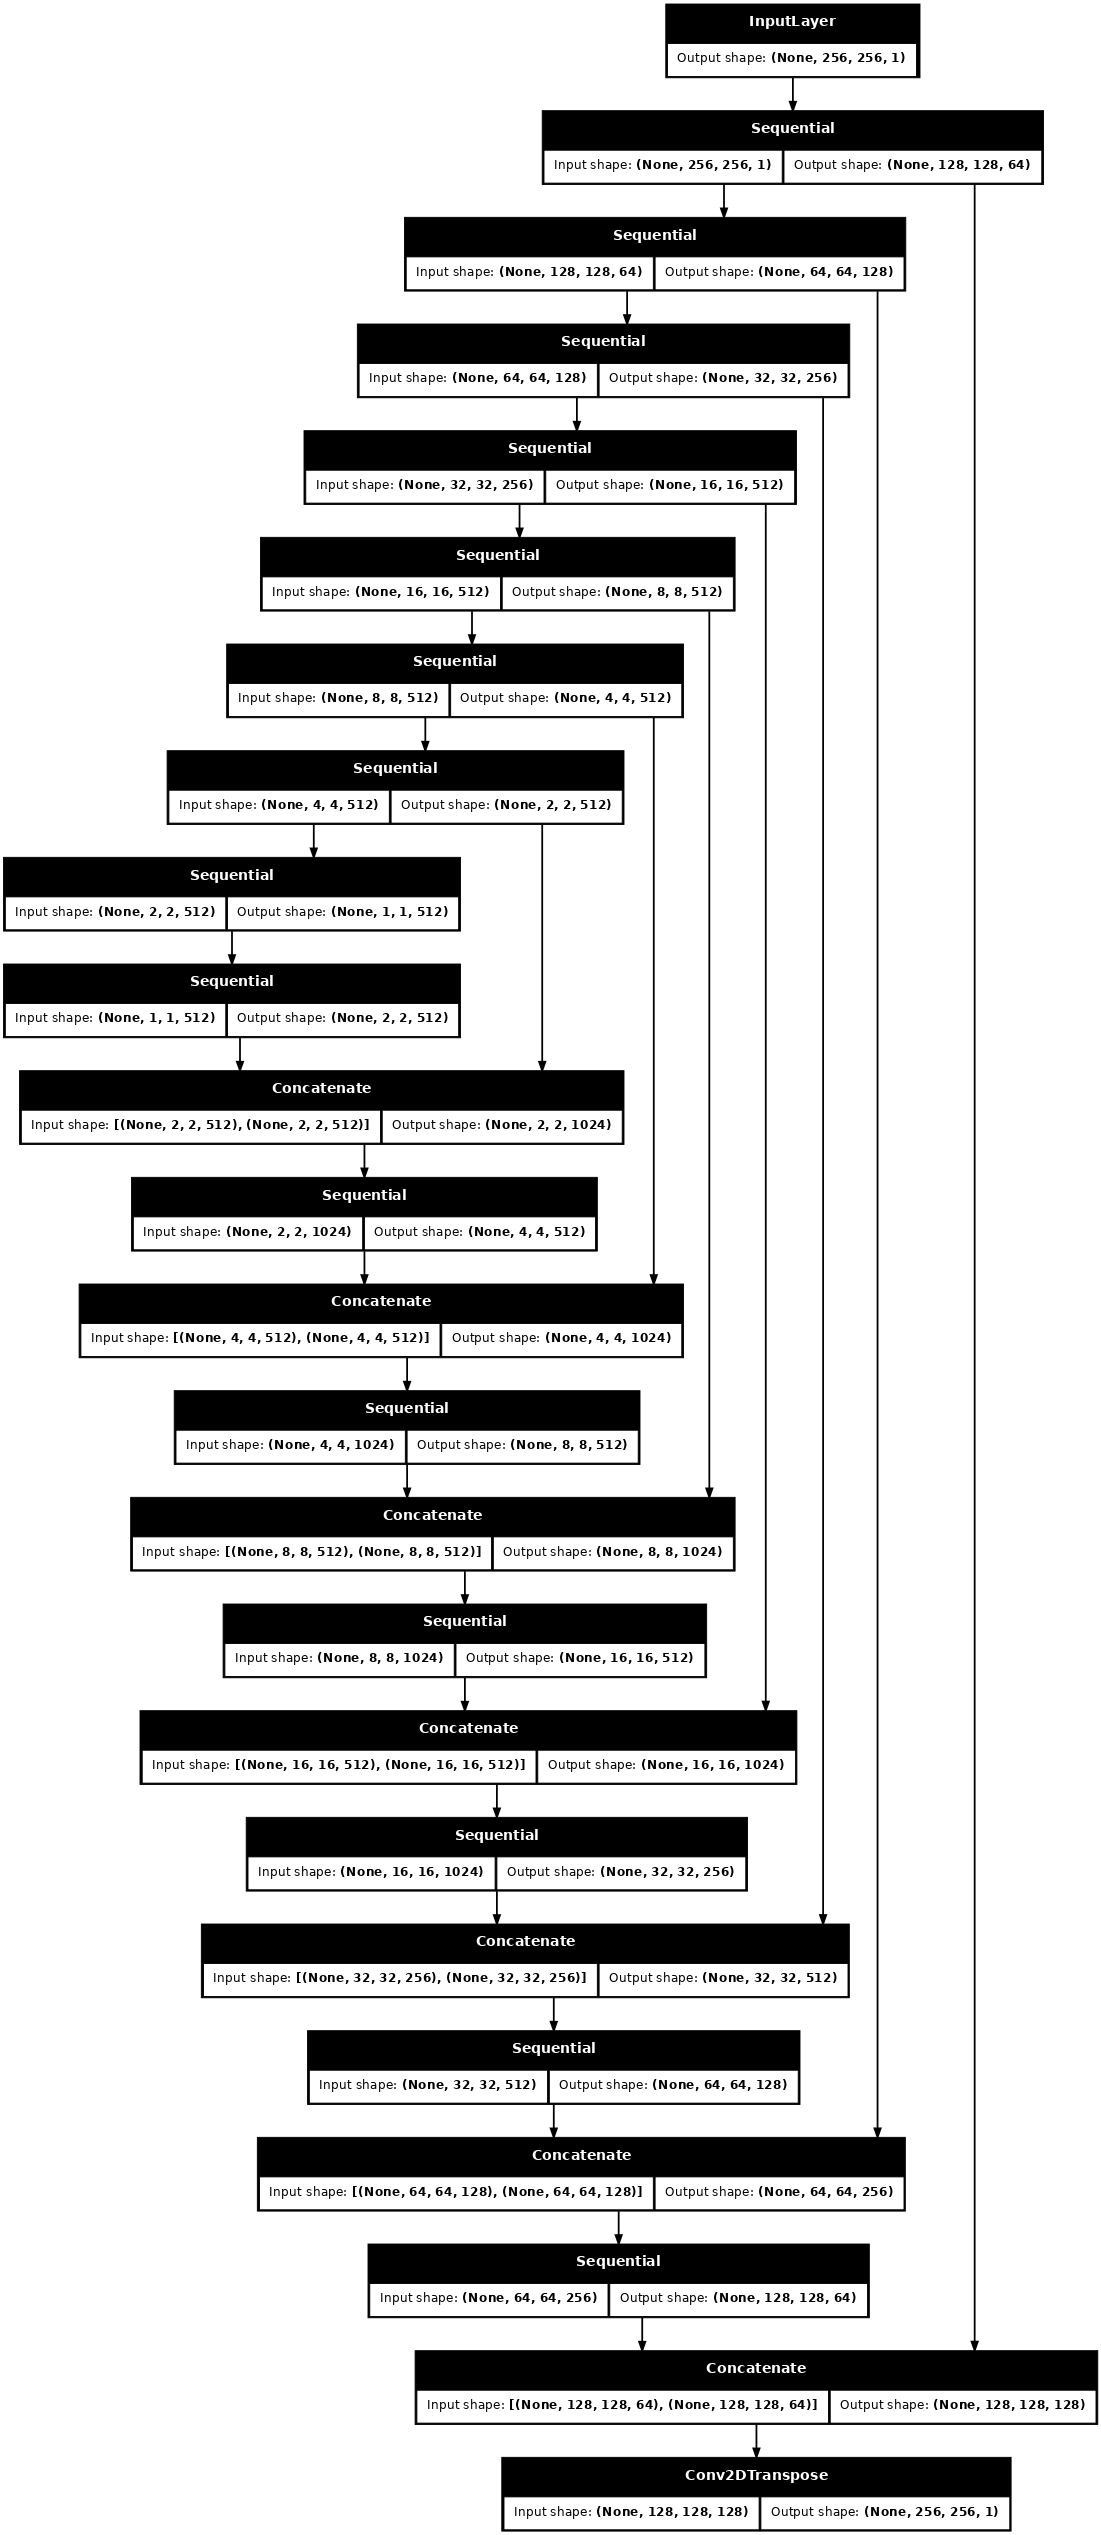

In [132]:
generator = Generator()
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64)

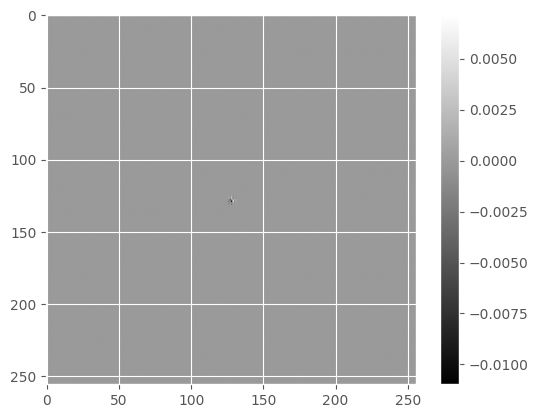

In [133]:
gen_output = generator(inp[tf.newaxis, ...], training=False)
plt.imshow(gen_output[0, ...], cmap='grey')
plt.colorbar()

In [134]:
LAMBDA_L1 = 30
LAMBDA_S = 15
LEARNING_RATE = 0.001
EPOCHS = 400

In [135]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [136]:
def sobel_operator(image_tensor):
    """Applies the Sobel operator to an image tensor."""

    sobel_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
    sobel_y = tf.constant([[-1,-2,-1], [0, 0, 0], [1, 2, 1]], dtype=tf.float32)

    # Reshape kernels for conv2d
    sobel_x = tf.reshape(sobel_x, [3, 3, 1, 1])
    sobel_y = tf.reshape(sobel_y, [3, 3, 1, 1])

    # Apply Sobel kernels
    grad_x = tf.nn.conv2d(image_tensor, sobel_x, strides=[1, 1, 1, 1], padding='SAME')
    grad_y = tf.nn.conv2d(image_tensor, sobel_y, strides=[1, 1, 1, 1], padding='SAME')

    # Calculate gradient magnitude
    gradient_magnitude = tf.sqrt(tf.square(grad_x) + tf.square(grad_y)) + 1e-5

    return gradient_magnitude

def generator_loss(disc_generated_output, gen_output, target):
  gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

  # Mean absolute error
  l1_loss = tf.reduce_mean(tf.abs(target - gen_output))

  # Apply Sobel operator
  gen_sobel = sobel_operator(gen_output)
  target_sobel = sobel_operator(target)

  # Calculate L1 loss on Sobel filtered images
  sobel_l1_loss = tf.reduce_mean(tf.abs(target_sobel - gen_sobel))

  total_gen_loss = gan_loss + (LAMBDA_L1 * l1_loss) + (LAMBDA_S * sobel_l1_loss)

  return total_gen_loss, gan_loss, l1_loss, sobel_l1_loss

In [137]:
def Discriminator():
  initializer = tf.random_normal_initializer(0., 0.02)

  inp = tf.keras.layers.Input(shape=[256, 256, 1], name='input_image')
  tar = tf.keras.layers.Input(shape=[256, 256, 1], name='target_image')

  x = tf.keras.layers.concatenate([inp, tar])  # (batch_size, 256, 256, channels*2)

  down1 = downsample(64, 4, False)(x)  # (batch_size, 128, 128, 64)
  down2 = downsample(128, 4)(down1)  # (batch_size, 64, 64, 128)
  down3 = downsample(256, 4)(down2)  # (batch_size, 32, 32, 256)

  zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3)  # (batch_size, 34, 34, 256)
  conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1)  # (batch_size, 31, 31, 512)

  batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

  leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

  zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)  # (batch_size, 33, 33, 512)

  last = tf.keras.layers.Conv2D(1, 2, strides=1,
                                kernel_initializer=initializer)(zero_pad2)  # (batch_size, 30, 30, 1)

  return tf.keras.Model(inputs=[inp, tar], outputs=last)

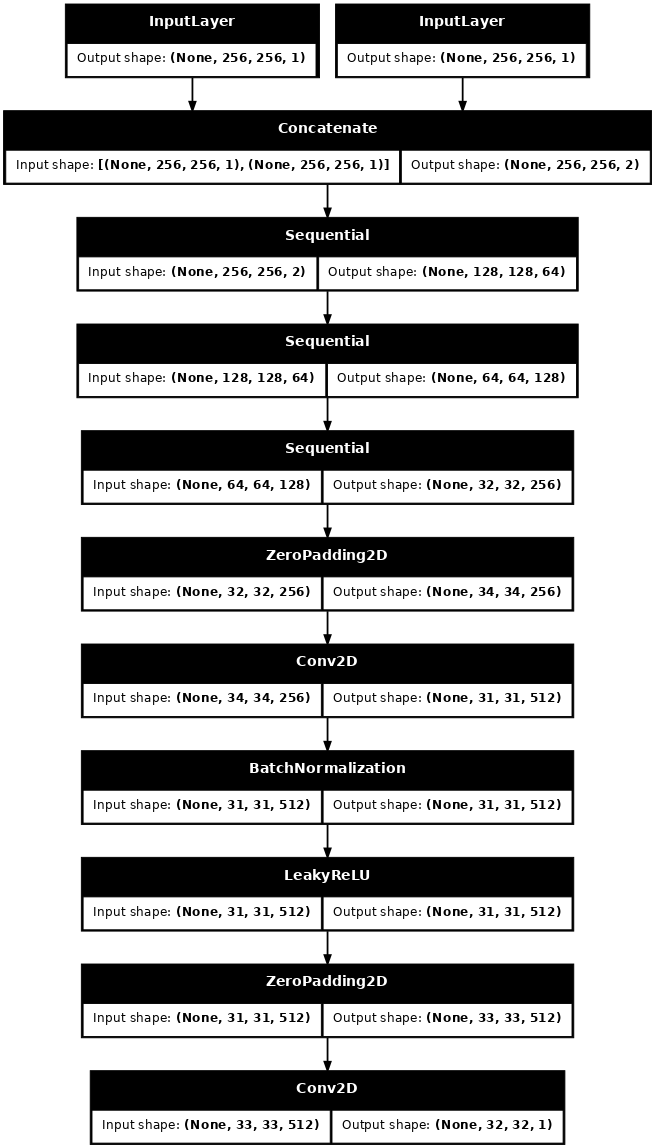

In [138]:
discriminator = Discriminator()
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64)

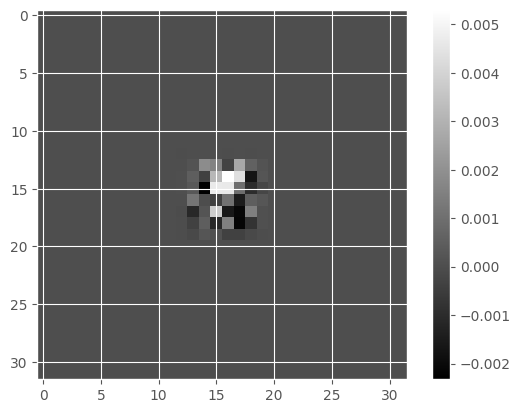

In [139]:
disc_out = discriminator([inp[tf.newaxis, ...], gen_output], training=False)
plt.imshow(disc_out[0, ..., -1], cmap='grey')
plt.colorbar()

In [140]:
def discriminator_loss(disc_real_output, disc_generated_output):
  real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)

  generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)

  total_disc_loss = real_loss + generated_loss

  return total_disc_loss

In [141]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=0.5)

In [142]:
checkpoint_dir = '../training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [143]:
def generate_images(model, test_input, tar):
  prediction = model(test_input, training=True)

  plt.figure(figsize=(15, 15))

#   diff = tar[0] - test_input[0]
  diff = tar[0] - prediction[0]

  display_list = [test_input[0], tar[0], prediction[0], diff]
  title = ['Input Image', 'Ground Truth', 'Predicted Image', 'Ground Truth - Predicted']

  for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.title(title[i])
    # Getting the pixel values in the [0, 1] range to plot.
    plt.imshow(display_list[i], vmin=-.5, vmax=.5, cmap='grey')
    plt.axis('off')

  plt.suptitle(f"Learning rate: {LEARNING_RATE}, Epochs: {EPOCHS}, λL1: {LAMBDA_L1}, λS: {LAMBDA_S}", fontsize=20, y=0.65)
  plt.tight_layout()
  plt.show()

## Training

In [144]:
log_dir="../logs/"

summary_writer = tf.summary.create_file_writer(
  log_dir + "fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

In [145]:
@tf.function
def train_step(input_image, target, step):
  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    gen_output = generator(input_image, training=True)

    disc_real_output = discriminator([input_image, target], training=True)
    disc_generated_output = discriminator([input_image, gen_output], training=True)

    gen_total_loss, gen_gan_loss, gen_l1_loss, sobel_l1_loss = generator_loss(disc_generated_output, gen_output, target)
    disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

  generator_gradients = gen_tape.gradient(gen_total_loss,
                                          generator.trainable_variables)
  discriminator_gradients = disc_tape.gradient(disc_loss,
                                               discriminator.trainable_variables)

  generator_optimizer.apply_gradients(zip(generator_gradients,
                                          generator.trainable_variables))
  discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                              discriminator.trainable_variables))

  with summary_writer.as_default():
    tf.summary.scalar('gen_total_loss', gen_total_loss, step=step)
    tf.summary.scalar('gen_gan_loss', gen_gan_loss, step=step)
    tf.summary.scalar('gen_l1_loss', gen_l1_loss, step=step)
    tf.summary.scalar('sobel_l1_loss', sobel_l1_loss, step=step)
    tf.summary.scalar('disc_loss', disc_loss, step=step)

In [146]:
def fit(train_ds, test_ds, steps):
  example_input, example_target = next(iter(test_ds.take(1)))
  start = time.time()

  for step, (input_image, target) in train_ds.repeat().take(steps).enumerate():
    if (step) % 100 == 0:
      display.clear_output(wait=True)

      if step != 0:
        print(f'Time taken for 100 steps: {time.time()-start:.2f} sec\n')

      start = time.time()

      generate_images(generator, example_input, example_target)
      print(f"Step: {step}")

    train_step(input_image, target, step)

    # Training step
    if (step+1) % 10 == 0:
      print('.', end='', flush=True)


    if (step + 1) % 100 == 0:
      checkpoint.save(file_prefix=checkpoint_prefix)

In [147]:
example_input, example_target = next(iter(test_dataset.take(1)))

Time taken for 100 steps: 28.91 sec



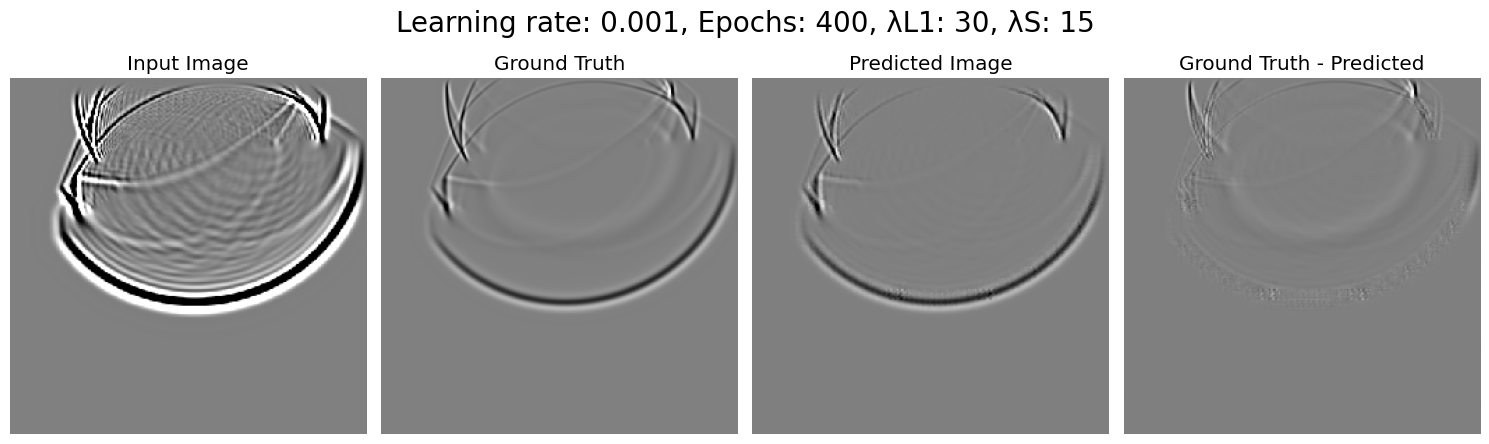

Step: 300
..........

2025-08-13 18:24:29.981947: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [148]:
fit(train_dataset, test_dataset, steps=EPOCHS)

In [149]:
# checkpoint_dir = '../training_checkpoints'
# checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
# checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
#                                  discriminator_optimizer=discriminator_optimizer,
#                                  generator=generator,
#                                  discriminator=discriminator)

In [150]:
# checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

### Old plots

In [151]:
# # dir = '../sample/constant_vel'
# dir = '../sample/parallel'
# # dir = '../sample/semi_circle'

# files = ['output_data_0_200.vti', 'output_data_0_300.vti', 'output_data_0_400.vti']

# for file in files:
#     print(file)
#     inp, re = load(f'{dir}/coarse_grid/{file}', f'{dir}/refined_grid/{file}')
#     generate_images(generator, inp[tf.newaxis, ...], re[tf.newaxis, ...])

In [152]:
# file = 'output_data_0_250.vti'

# inp, re = load(f'{dir}/coarse_grid/{file}', f'{dir}/refined_grid/{file}')

# prediction = generator(inp[tf.newaxis, ...], training=True)[0]

# def normalize_wavefield(wavefield):
#     return (wavefield - tf.reduce_min(wavefield)) / \
#            (tf.reduce_max(wavefield) - tf.reduce_min(wavefield))

# inp_norm = normalize_wavefield(inp)
# re_norm = normalize_wavefield(re)
# pred_norm = normalize_wavefield(prediction)

# plt.figure(figsize=(15,5))
# plt.subplot(1,3,1); plt.imshow((sobel_operator(inp_norm[tf.newaxis]) * 5.0)[0,...,0],
#                     vmin=0, vmax=1, cmap='viridis')
# plt.title('Input Sobel')
# plt.colorbar()

# plt.subplot(1,3,2); plt.imshow((sobel_operator(re_norm[tf.newaxis])* 5.0)[0,...,0],
#                     vmin=0, vmax=1, cmap='viridis')
# plt.title('GT Sobel')
# plt.colorbar()

# plt.subplot(1,3,3); plt.imshow((sobel_operator(pred_norm[tf.newaxis])* 5.0)[0,...,0],
#                     vmin=0, vmax=1, cmap='viridis')
# plt.title('Pred Sobel')
# plt.colorbar()

## Generate Results

In [153]:
plt.style.use('ggplot')

def plot_result(input_image):
    plt.grid(False)
    plt.gca().invert_yaxis()
    plt.gca().xaxis.set_ticks_position('top')
    plt.imshow(
        input_image,
        vmin=-.2,
        vmax=.2,
        cmap='magma',
        # extent=[0, 3000, 3000, 0]
        extent=[0, 6000, 6000, 0]
    )
    plt.xlabel('X (m)')
    plt.gca().xaxis.set_label_position('top')
    plt.ylabel('Z (m)')
    plt.colorbar()
    plt.show()

def calculate_accuracy(prediction, ground_truth, print_results=True):
    # Ensure both are numpy arrays
    pred = prediction.numpy() if isinstance(prediction, tf.Tensor) else prediction
    gt = ground_truth.numpy() if isinstance(ground_truth, tf.Tensor) else ground_truth

    # Remove channel dimension if present
    if pred.ndim == 3 and pred.shape[-1] == 1:
        pred = pred[..., 0]
    if gt.ndim == 3 and gt.shape[-1] == 1:
        gt = gt[..., 0]

    rmse = np.sqrt(np.mean((pred - gt) ** 2))
    norm = gt.max() - gt.min()
    nrmse_val = rmse / norm if norm != 0 else np.nan

    if print_results:
        print(f"NRMSE: {nrmse_val:.6f} or {nrmse_val * 100:.2f}%")

    return nrmse_val


t = 1.65 s


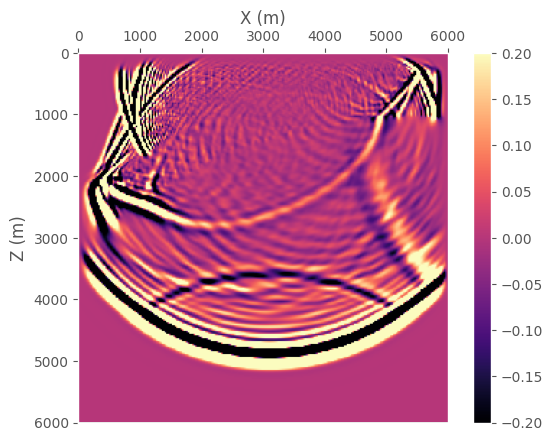

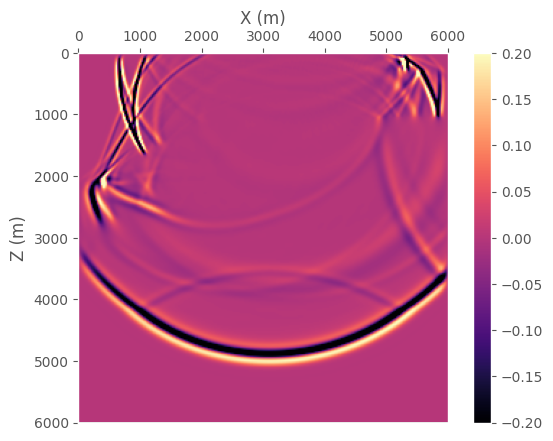

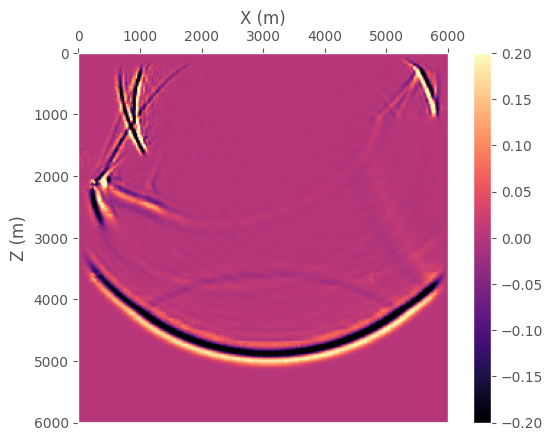

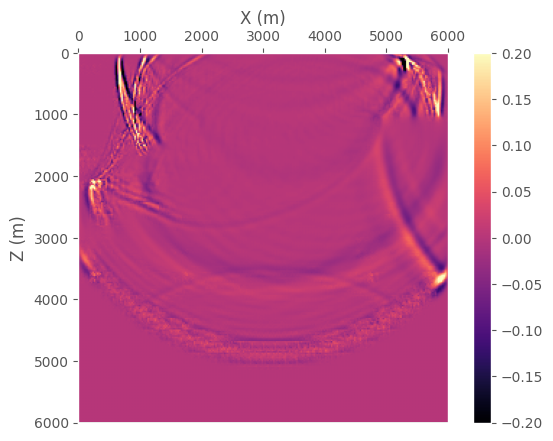

Accuracy of the raw data:
NRMSE: 0.216859 or 21.69%
Accuracy of the prediction:
NRMSE: 0.014550 or 1.46%


np.float32(0.014550409)

In [154]:
k = 600
t = k * 0.00025 * 11

# vel_model = 'constant_vel'
# vel_model = 'parallel'
# vel_model = 'semicircle'
# vel_model = 'bent'
vel_model = 'reservoir'

raw = f'../sample/{vel_model}/coarse_grid/output_data_0_{k}.vti'
target = f'../sample/{vel_model}/refined_grid/output_data_0_{k}.vti'

inp, re = load(raw, target)
prediction = generator(inp[tf.newaxis, ...], training=True)[0]

print(f"t = {t} s")

plot_result(inp)
plot_result(re)
plot_result(prediction)

plot_result(prediction - re)

print("Accuracy of the raw data:")
calculate_accuracy(inp, re)

print("Accuracy of the prediction:")
calculate_accuracy(prediction, re)

In [155]:
# files = sorted(os.listdir(f'../sample/{vel_model}/coarse_grid/'))
# files = [f for f in files if f.startswith('output_data_0_') and f.endswith('.vti')]
# nrmse_inp = []
# nrmse_pred = []
# for file in files:
#     inp, re = load(
#         f'../sample/{vel_model}/coarse_grid/{file}',
#         f'../sample/{vel_model}/refined_grid/{file}'
#     )
#     prediction = generator(inp[tf.newaxis, ...], training=True)[0]

In [156]:
files = sorted(os.listdir(f'../sample/{vel_model}/coarse_grid/'))
files = [f for f in files if f.startswith('output_data_0_') and f.endswith('.vti')]
nrmse_inp = []
nrmse_pred = []
for file in files:
    inp, re = load(
        f'../sample/{vel_model}/coarse_grid/{file}',
        f'../sample/{vel_model}/refined_grid/{file}'
    )
    prediction = generator(inp[tf.newaxis, ...], training=True)[0]

    nrmse_inp_val = calculate_accuracy(inp, re, print_results=False)
    nrmse_inp_percent = nrmse_inp_val * 100
    if nrmse_inp_percent > 0 and nrmse_inp_percent < 100:
        nrmse_inp.append(nrmse_inp_percent)

    nrmse_pred_val = calculate_accuracy(prediction, re, print_results=False)
    nrmse_pred_percent = nrmse_pred_val * 100
    if nrmse_pred_percent > 0 and nrmse_pred_percent < 100:
        nrmse_pred.append(nrmse_pred_percent)

print(f"Mean NRMSE for {vel_model} - Input: {np.mean(nrmse_inp):.6f}, Prediction: {np.mean(nrmse_pred):.6f}")


Mean NRMSE for reservoir - Input: 19.602318, Prediction: 1.564487


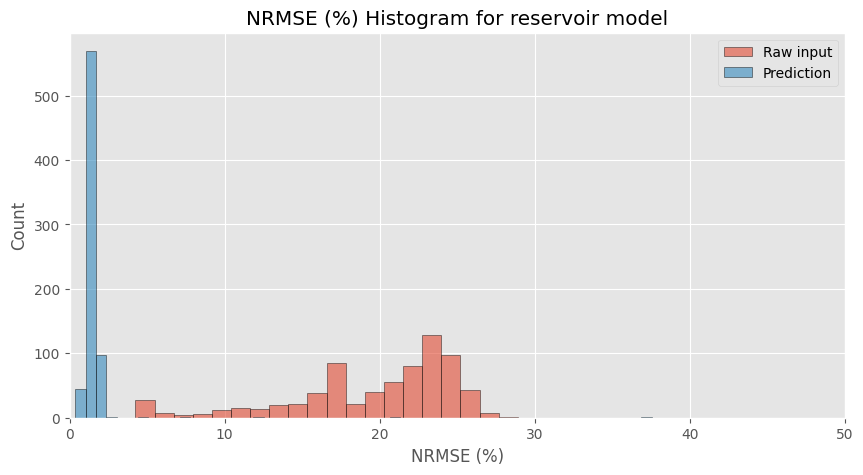

In [157]:
plt.figure(figsize=(10, 5))
plt.hist(nrmse_inp, bins=20, alpha=0.6, label='Raw input', edgecolor='black')
plt.hist(nrmse_pred, bins=100, alpha=0.6, label='Prediction', edgecolor='black')
plt.xlabel('NRMSE (%)')
plt.ylabel('Count')
plt.title(f'NRMSE (%) Histogram for {vel_model} model')
plt.xlim([0, 50])
plt.legend()
plt.show()

## Generating Results (Old)

In [158]:
# def tensor_to_uniform_grid(tensor, reference_grid):
#     arr = tensor.numpy()

#     # Remove channel dimension if present
#     if arr.ndim == 4 and arr.shape[-1] == 1:
#         arr = np.squeeze(arr, axis=-1)  # shape: (Z, Y, X)

#     # Transpose from (Z, Y, X) → (X, Y, Z)
#     arr = arr.transpose(2, 1, 0)

#     # dims = reference_grid.dimensions  # should be (X, Y, Z)
#     dims = (256, 256, 1)
#     if arr.shape != tuple(dims):
#         raise ValueError(f"Tensor shape {arr.shape} does not match grid dimensions {dims}")

#     # Build new grid
#     new_grid = pv.ImageData()
#     new_grid.origin = reference_grid.origin
#     new_grid.spacing = reference_grid.spacing
#     new_grid.dimensions = dims
#     new_grid.point_data["ProcessedData"] = arr.flatten(order="F")

#     return new_grid

# def generate_results(model, input_dir, output_dir):
#     os.makedirs(output_dir, exist_ok=True)

#     for filename in os.listdir(input_dir):
#         input_path = os.path.join(input_dir, filename)
#         grid = pv.read(input_path)
#         inp, _ = load(input_path)
#         prediction = model(inp[tf.newaxis, ...], training=True)
#         # prediction = tf.image.resize(prediction, [200, 200],
#         #                         method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
#         # print(prediction)
#         output_path = os.path.join(output_dir, filename)
#         processed_grid = tensor_to_uniform_grid(prediction, grid)
#         processed_grid.save(output_path)
#         print(f"Saved: {output_path}")

#     print(f"Successfully processed all .vti files in {input_dir} into {output_dir}")


### Constant Velocity

In [159]:
# generate_results(generator, './sample/constant_vel/coarse_grid', './results/constant_vel')


### Parallel Planes

In [160]:
# generate_results(generator, './sample/parallel_planes/coarse_grid', './results/parallel_planes')